# Notebook for Testing Mask Values for Data

## Import Necessary Packages

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d

import trxrd
from globals import *

%matplotlib widget

## Define File Paths

In [2]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}*.tif"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

# Detector mask file
mask_file = MASK_FILE
print(f"Using mask file: {mask_file}")

4 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\CeO2.
Using mask file: C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif


## Import Images

In [3]:
data_dict = trxrd.get_images_by_scan_name(
    folder_path=DATA_PATH,
    scan_name=SCAN_NAME,
    sort=True,
    filter_data=False,
    plot=False,
)

print(data_dict.keys())
print("Images shape:", data_dict["images"].shape)
print("Counts shape:", data_dict["counts"].shape)

4 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\CeO2 with scan name CeO2_good.
dict_keys(['images', 'counts', 'file_names'])
Images shape: (4, 1679, 1475)
Counts shape: (4,)


## Build Combined Masks

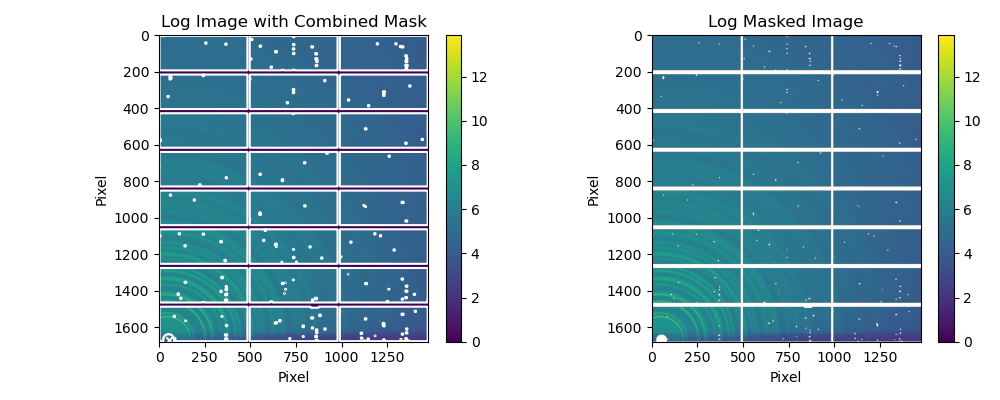

In [4]:
image_shape = data_dict["images"].shape[1:]   # (rows, cols)

combined_mask = trxrd.build_combined_mask(
    image_shape,
    center_xy = (MASK_CENTER_X, MASK_CENTER_Y),
    radius = MASK_RADIUS,
    detector_mask=None,
    mask_path=MASK_FILE,
    plot=True,
    example_image=data_dict["images"][0],
)

## Find Centers for Images

Finding centers for 4 images...
  Completed 4/4 (100.0%)
Done finding centers.


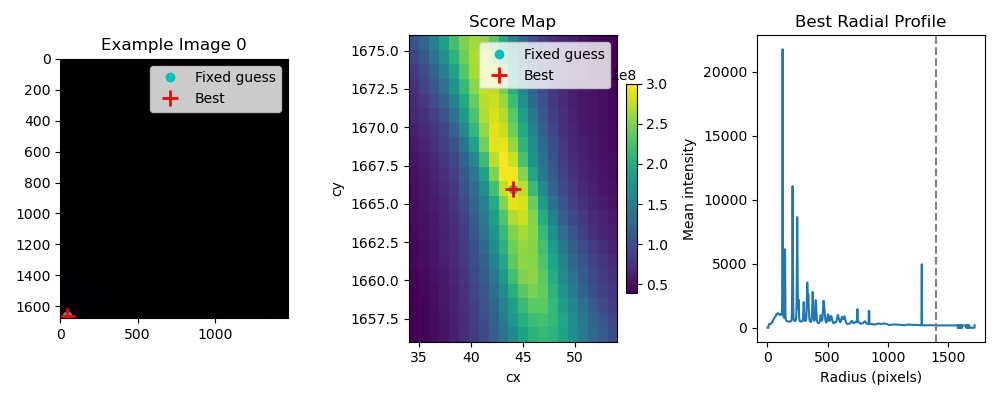

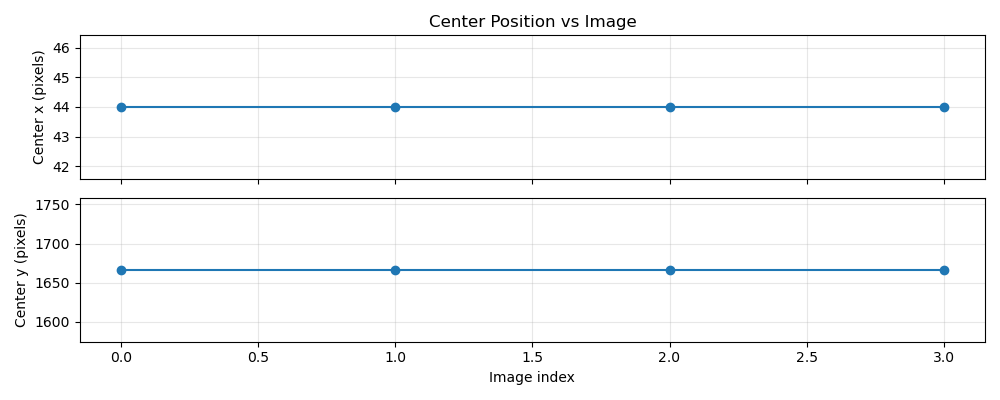

Centers shape: (4, 2)
First center: [  44. 1666.]
Mean center: [  44. 1666.]


In [5]:
center_result = trxrd.find_centers_in_stack_radial_parallel(
    data_array=data_dict["images"],
    center_guess_yx=(CENTER_Y, CENTER_X),   # note: (y, x)
    search_radius=10,
    center_mask=None,
    r_min=0,
    r_max=1400,
    downsample=1,
    intensity_threshold=None,
    top_percentile=60,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
    plot_example=True,
    example_index=0,
    plot_center_vs_image=True,
)

centers = center_result["centers_xy"]
print("Centers shape:", centers.shape)
print("First center:", centers[0])
mean_center = np.mean(centers, axis=0)
print(f"Mean center: {mean_center}")


## Compute Azimuthal Average

Integrating 4 images...
  Completed 4/4 (100.0%)
Done integrating.
q shape: (3000,)
profiles shape: (4, 3000)


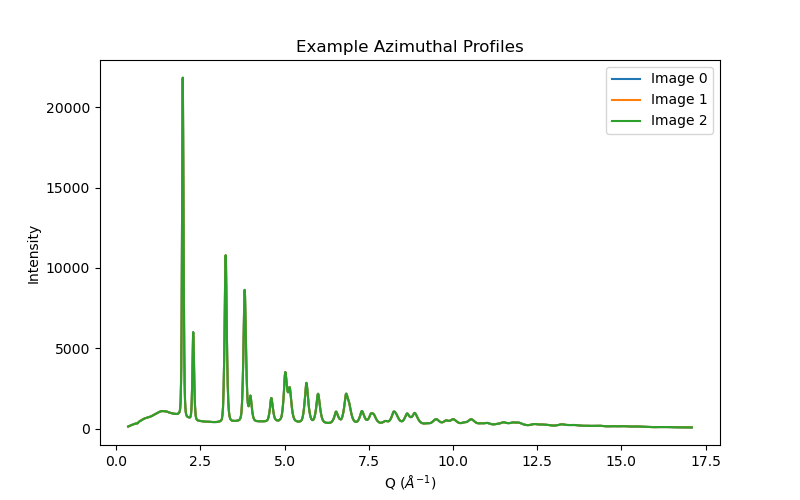

In [6]:
az_result = trxrd.azimuthal_average_pyfai(
    images=data_dict["images"],
    centers_xy=(CENTER_X, CENTER_Y),   # note: (x, y)
    polarization_factor=POLARIZATION_FACTOR,
    npt=N_POINTS,
    unit=UNIT,
    nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
    azimuth_range=None,
    integration_mask=combined_mask,
    return_dict=True,
    progress_interval=100,
    use_custom_polarization=False,
    integration_function="integrate1d",
    correct_solid_angle=False,
    method=("bbox", "csr", "cython")
)

q = az_result["radial"]
profiles = az_result["profiles"]

print("q shape:", q.shape)
print("profiles shape:", profiles.shape)

plt.figure(figsize=(8, 5))
for i in [0, 1, 2]:
    plt.plot(q, profiles[i], label=f"Image {i}")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Intensity")
plt.title("Example Azimuthal Profiles")
plt.legend()
plt.show()

## Normalize Azimuthal Averages

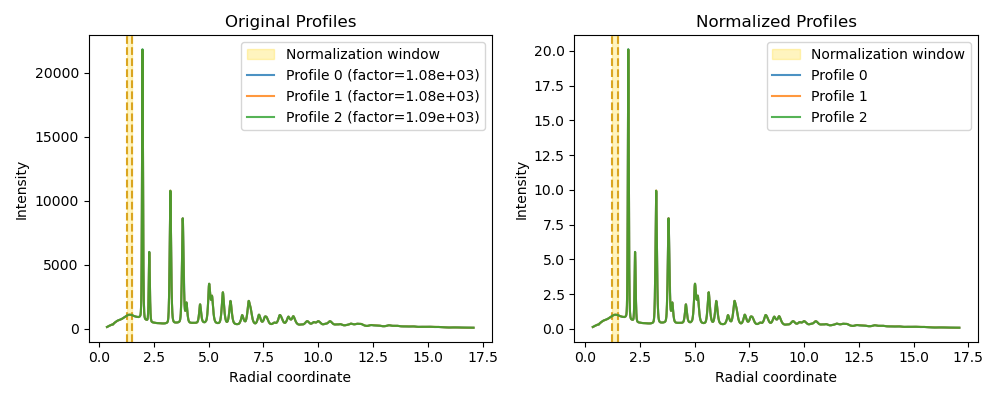

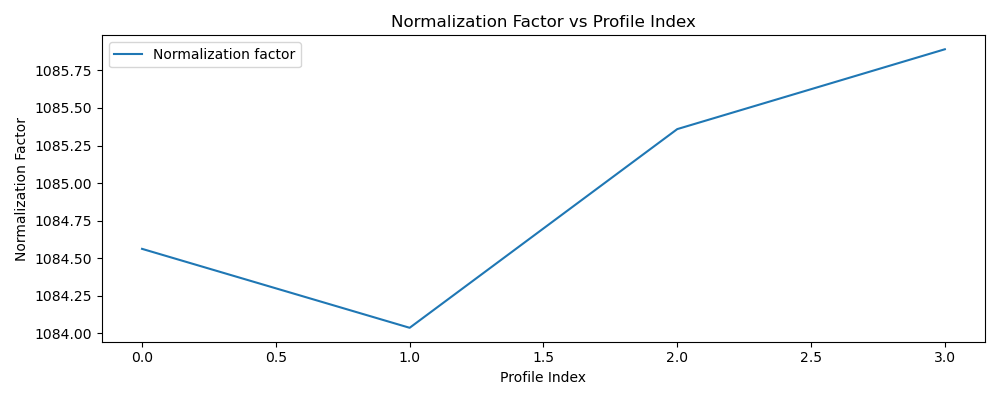

In [7]:
norm_result = trxrd.normalize_profiles_to_range(
    radial=q,
    profiles=profiles,
    norm_range=(1.25, 1.5),   # example
    mode="mean",
    plot=True,
    plot_indices=[0, 1, 2],
    show_normalized_plot=True,
    return_dict=True,
    plot_factors=True,
)

profiles_norm = norm_result["normalized_profiles"]

## Load and Prepare Background Image(s)

dict_keys(['files', 'background_stack', 'background_mean', 'background_std', 'n_images'])
Background stack shape: (1, 1679, 1475)
Background mean shape: (1679, 1475)
Integrating 1 images...


C:\Users\lheald\AppData\Local\Temp\ipykernel_18872\2878563893.py:21: RuntimeWarning: Mean of empty slice
  bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


  Completed 1/1 (100.0%)
Done integrating.


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:2748: RuntimeWarning: Mean of empty slice
  background_profile_mean = np.nanmean(background_profiles, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


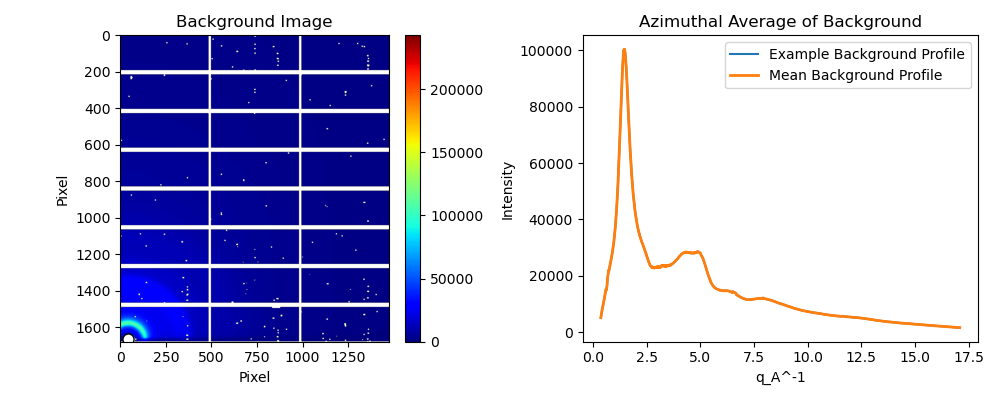

In [8]:
# Background path can be either:
# - a single tif file
# - or a folder containing many background tif files
# Load Data
bg_dict = trxrd.load_background(
    background_path=BACKGROUND_PATH,
    sort=True,
    plot=False,
)

print(bg_dict.keys())
print("Background stack shape:", bg_dict["background_stack"].shape)
print("Background mean shape:", bg_dict["background_mean"].shape)

bg_dict["background_stack"] = trxrd.apply_mask_from_bool(
    data_array=bg_dict["background_stack"],
    mask_bool=combined_mask,
)


bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


# Compute background azimuthal average
bg_az_result = trxrd.compute_background_azimuthal_average(
    background_input=bg_dict["background_stack"],
    centers_xy=(CENTER_X, CENTER_Y),   # one average center in (x, y)
    unit=UNIT,
    polarization_factor=POLARIZATION_FACTOR,
    npt=N_POINTS,
    use_custom_polarization=False,
    integration_function="integrate1d",
    correct_solid_angle=False,
    plot=True,
)

q_bg = bg_az_result["radial"]
background_profile = bg_az_result["background_profile_mean"]



## Subtract Scaled Background from Images

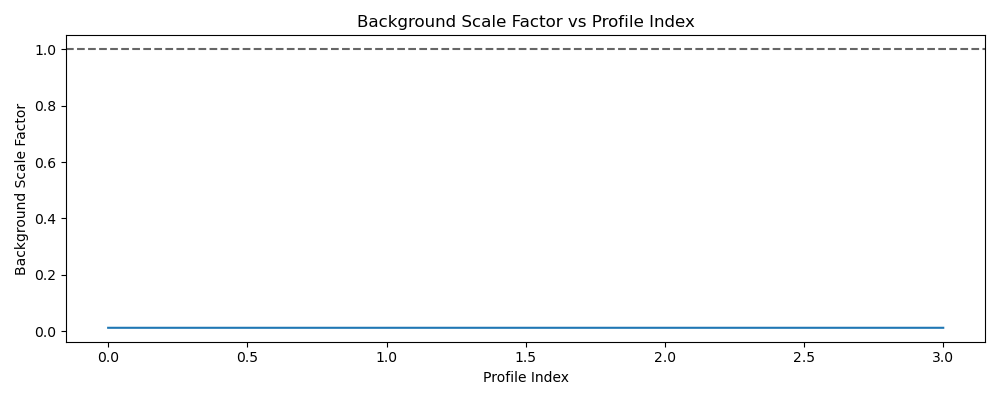

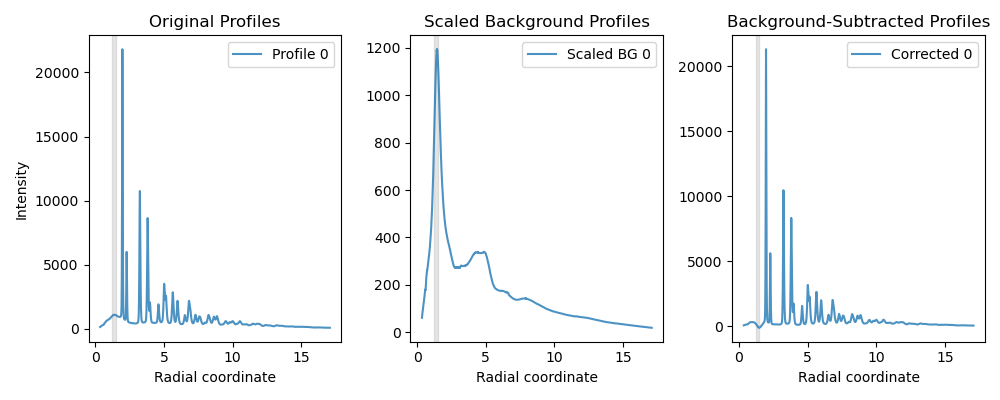

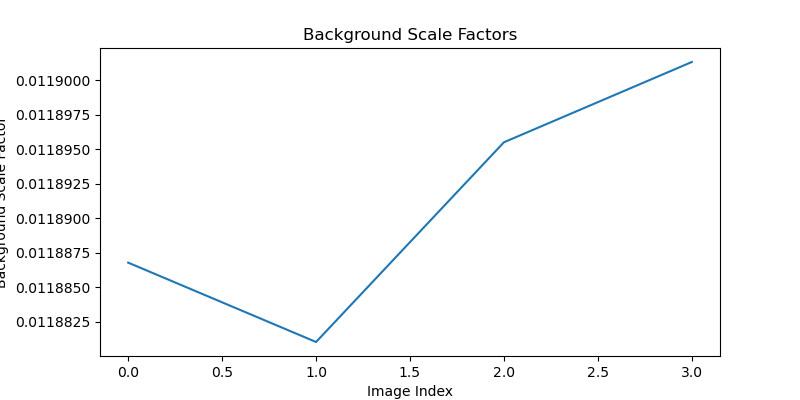

In [9]:
bgsub_result = trxrd.subtract_scaled_background_profile(
    radial=q,
    profiles=profiles,
    background_profile=background_profile,
    norm_range=(1.25, 1.5),   # example region; adjust as needed
    mode="mean",
    scale_method="ratio",
    plot=True,
    plot_scale_factors=True,
    plot_indices=[0],
    return_dict=True,
)

profiles_bgsub = bgsub_result["corrected_profiles"]
baselines = bgsub_result["scaled_background_profiles"]

# Inspect Scaling Factors
plt.figure(figsize=(8, 4))
plt.plot(bgsub_result["scale_factors"])
plt.xlabel("Image Index")
plt.ylabel("Background Scale Factor")
plt.title("Background Scale Factors")
plt.show()

## Save Background

In [10]:
df = pd.DataFrame({
    "q": q_bg,
    "I(q)": baselines[0]/1000   # example: save the baseline for the first image
})

df.to_csv(
    f"{SCAN_NAME}_background.dat",
    sep=" ",
    index=False
)